In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tqdm as tq
from scipy.stats import spearmanr

In [9]:
arabidopsis_tomato_nm = pd.read_csv('C:\\Users\\mikep\\Data\\Data_for_review\\tomato_to_arabidopsis_ortholog_NM.csv')
arabidopsis_tomato_nm

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200
1,4081_0:0062c9,3702_0:006584,10009at3193,LOC101249449,AT5G42200
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910
4,4081_0:0060db,3702_0:0018a2,10147at3193,LOC101260909,AT1G18450
...,...,...,...,...,...
53425,4081_0:003f8c,3702_0:003134,9942at3193,LOC101261051,AT3G59920
53426,4081_0:005b8a,3702_0:003134,9942at3193,LOC101259410,AT3G59920
53427,4081_0:000a73,3702_0:005540,9942at3193,GDI1,AT5G09550
53428,4081_0:003f8c,3702_0:005540,9942at3193,LOC101261051,AT5G09550


In [10]:
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'arabidopsis Symbol',)
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'tomato Symbol',)
arabidopsis_tomato_nm

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910
5,4081_0:001ce5,3702_0:000573,10228at3193,LOC101262196,AT1G49040
6,4081_0:00485f,3702_0:0012bf,10238at3193,LOC101260971,AT1G79120
...,...,...,...,...,...
53411,4081_0:001e35,3702_0:00121f,9828at3193,LOC101268561,AT1G74750
53413,4081_0:00467b,3702_0:0052b3,9836at3193,LOC101260957,AT5G11380
53414,4081_0:003e73,3702_0:001def,9877at3193,LOC101258079,AT2G42790
53420,4081_0:00201e,3702_0:00114d,9919at3193,LOC101252265,AT1G15440


In [73]:
arabi_csv_uncleaned = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\GSE94015_gene_readCount.txt",
    sep="\t",
)
arabi_csv = arabi_csv_uncleaned[
    [
        "Locus",
        "WtRL0h_rep1",
        "WtRL0h_rep2",
        "WtRL0h_rep3",
        "WtRL3h_rep1",
        "WtRL3h_rep2",
        "WtRL3h_rep3",
    ]
]

arabi_csv = arabi_csv.set_index('Locus')
arabi_csv

,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3
Locus,,,,,,
AT1G01010,92,212,255,79,154,169
AT1G01020,120,288,219,219,354,597
AT1G01030,3,28,15,5,9,14
AT1G01040,889,2127,2189,1041,1788,1807
AT1G01046,12,51,37,8,26,19
...,...,...,...,...,...,...
ATMG01370,18,59,67,218,382,249
ATMG01380,13,8,14,104,136,107
ATMG01390,382,1046,4054,5581,8779,4796


In [5]:
arabi_metadata = pd.DataFrame(
    columns=["Temp"],
    data=["Cold", "Cold", "Cold", "Hot", "Hot", "Hot"],
    index=[
        "WtRL0h_rep1",
        "WtRL0h_rep2",
        "WtRL0h_rep3",
        "WtRL3h_rep1",
        "WtRL3h_rep2",
        "WtRL3h_rep3",
    ],
)

In [6]:
low_heat_tomato_1 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\low_heat_tomato\\tomato_no_heat_stress_1ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
low_heat_tomato_2 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\low_heat_tomato\\tomato_no_heat_stress_2ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
low_heat_tomato_3 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\low_heat_tomato\\tomato_no_heat_stress_3ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)

low_heat_tomato = pd.DataFrame(
    data=zip(
        low_heat_tomato_1["Reads"],
        low_heat_tomato_2["Reads"],
        low_heat_tomato_3["Reads"],
    ),
    columns=["Tom Cold Rep 1", "Tom Cold Rep 2", "Tom Cold Rep 3"],
    index=low_heat_tomato_1.index,
)
low_heat_tomato

,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3
LOC104645797,0,0,0
GAD3,400,322,552
LOC101263636,1838,1674,1865
sos1,400,391,332
LOC101263144,201,200,179
...,...,...,...
LyesC2p005,0,0,0
LyesC2p004,0,3,0
LyesC2t045,0,0,0
LyesC2p003,0,1,6


In [32]:
high_heat_tomato_rep_1 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\high_heat_tomato\\tomato_heat_stress_1ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
high_heat_tomato_rep_2 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\high_heat_tomato\\tomato_heat_stress_2ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
high_heat_tomato_rep_3 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\high_heat_tomato\\tomato_heat_stress_3ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
high_heat_tomato = pd.DataFrame(
    data=zip(
        high_heat_tomato_rep_1["Reads"],
        high_heat_tomato_rep_2["Reads"],
        high_heat_tomato_rep_3["Reads"],
    ),
    columns=["Tom Hot Rep 1", "Tom Hot Rep 2", "Tom Hot Rep 3"],
    index=low_heat_tomato_1.index,
)

In [35]:
full_tomato = pd.concat([low_heat_tomato, high_heat_tomato], axis = 1)
full_tomato

,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
LOC104645797,0,0,0,0,0,0
GAD3,400,322,552,879,462,743
LOC101263636,1838,1674,1865,444,383,379
sos1,400,391,332,904,648,702
LOC101263144,201,200,179,996,784,684
...,...,...,...,...,...,...
LyesC2p005,0,0,0,0,0,0
LyesC2p004,0,3,0,0,0,0
LyesC2t045,0,0,0,0,0,0
LyesC2p003,0,1,6,0,0,1


In [33]:
high_heat_tomato

,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
LOC104645797,0,0,0
GAD3,879,462,743
LOC101263636,444,383,379
sos1,904,648,702
LOC101263144,996,784,684
...,...,...,...
LyesC2p005,0,0,0
LyesC2p004,0,0,0
LyesC2t045,0,0,0
LyesC2p003,0,0,1


In [23]:
tomato_csv_mean

,Tomato Expression
LOC104645797,0.000000
GAD3,424.666667
LOC101263636,1792.333333
sos1,374.333333
LOC101263144,193.333333
...,...
LyesC2p005,0.000000
LyesC2p004,1.000000
LyesC2t045,0.000000
LyesC2p003,2.333333


In [17]:
arabi_csv_mean

,Arabidopsis Expression
Locus,
AT1G01010,186.333333
AT1G01020,209.000000
AT1G01030,15.333333
AT1G01040,1735.000000
AT1G01046,33.333333
...,...
ATMG01370,48.000000
ATMG01380,11.666667
ATMG01390,1827.333333


In [14]:
arabidopsis_tomato_nm

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910
5,4081_0:001ce5,3702_0:000573,10228at3193,LOC101262196,AT1G49040
6,4081_0:00485f,3702_0:0012bf,10238at3193,LOC101260971,AT1G79120
...,...,...,...,...,...
53411,4081_0:001e35,3702_0:00121f,9828at3193,LOC101268561,AT1G74750
53413,4081_0:00467b,3702_0:0052b3,9836at3193,LOC101260957,AT5G11380
53414,4081_0:003e73,3702_0:001def,9877at3193,LOC101258079,AT2G42790
53420,4081_0:00201e,3702_0:00114d,9919at3193,LOC101252265,AT1G15440


In [36]:
arabidopsis_tomato_nm_merged_arabi = arabidopsis_tomato_nm.merge(how = 'inner', left_on = 'arabidopsis Symbol', right_on= 'Locus', right = arabi_csv, )

In [37]:
arabidopsis_tomato_nm_merged_both = arabidopsis_tomato_nm_merged_arabi.merge(how = 'inner', left_on = 'tomato Symbol', right_index = True, right = full_tomato )

In [38]:
arabidopsis_tomato_nm_merged_both

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200,54,92,32,41,315,109,204,101,192,279,286,272
1,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300,595,1225,1644,678,1741,1613,293,275,280,338,284,279
2,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910,1,3,1,11,22,2,262,409,319,800,777,821
3,4081_0:001ce5,3702_0:000573,10228at3193,LOC101262196,AT1G49040,762,1548,1515,435,825,1000,682,774,656,1683,1524,1251
4,4081_0:00485f,3702_0:0012bf,10238at3193,LOC101260971,AT1G79120,3,5,9,3,29,16,6,2,1,36,34,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10377,4081_0:001e35,3702_0:00121f,9828at3193,LOC101268561,AT1G74750,109,253,296,99,156,239,357,449,306,369,386,255
10378,4081_0:00467b,3702_0:0052b3,9836at3193,LOC101260957,AT5G11380,249,341,441,243,502,538,196,181,197,778,584,568
10379,4081_0:003e73,3702_0:001def,9877at3193,LOC101258079,AT2G42790,1330,2203,2510,1924,3815,3271,119,108,77,68,28,57
10380,4081_0:00201e,3702_0:00114d,9919at3193,LOC101252265,AT1G15440,88,304,343,536,689,1062,37,42,14,324,308,243


In [40]:
shuffled_tomato = arabidopsis_tomato_nm_merged_both[["Tom Cold Rep 1", "Tom Cold Rep 2", "Tom Cold Rep 3", "Tom Hot Rep 1", "Tom Hot Rep 2", "Tom Hot Rep 3"]].sample(frac = 1)
shuffled_df = pd.concat([arabidopsis_tomato_nm_merged_both[['Orthogroup','WtRL0h_rep1','WtRL0h_rep2','WtRL0h_rep3','WtRL3h_rep1','WtRL3h_rep2','WtRL3h_rep3']], shuffled_tomato], axis = 1)
shuffled_df

,Orthogroup,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
0,10009at3193,54,92,32,41,315,109,204,101,192,279,286,272
1,10092at3193,595,1225,1644,678,1741,1613,293,275,280,338,284,279
2,10147at3193,1,3,1,11,22,2,262,409,319,800,777,821
3,10228at3193,762,1548,1515,435,825,1000,682,774,656,1683,1524,1251
4,10238at3193,3,5,9,3,29,16,6,2,1,36,34,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10377,9828at3193,109,253,296,99,156,239,357,449,306,369,386,255
10378,9836at3193,249,341,441,243,502,538,196,181,197,778,584,568
10379,9877at3193,1330,2203,2510,1924,3815,3271,119,108,77,68,28,57
10380,9919at3193,88,304,343,536,689,1062,37,42,14,324,308,243


In [52]:
zero_counts = (shuffled_df.drop(columns=["Orthogroup"]) == 0).sum(axis=1)
shuffled_df = shuffled_df.loc[zero_counts <= 1].copy()
shuffled_df

,Orthogroup,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
0,10009at3193,54,92,32,41,315,109,204,101,192,279,286,272
1,10092at3193,595,1225,1644,678,1741,1613,293,275,280,338,284,279
2,10147at3193,1,3,1,11,22,2,262,409,319,800,777,821
3,10228at3193,762,1548,1515,435,825,1000,682,774,656,1683,1524,1251
4,10238at3193,3,5,9,3,29,16,6,2,1,36,34,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10377,9828at3193,109,253,296,99,156,239,357,449,306,369,386,255
10378,9836at3193,249,341,441,243,502,538,196,181,197,778,584,568
10379,9877at3193,1330,2203,2510,1924,3815,3271,119,108,77,68,28,57
10380,9919at3193,88,304,343,536,689,1062,37,42,14,324,308,243


In [53]:
## genewise correlations
list_of_genewise_correlations = []
for row in shuffled_df.iterrows():
    arabi_array = row[1][['WtRL0h_rep1','WtRL0h_rep2','WtRL0h_rep3','WtRL3h_rep1','WtRL3h_rep2','WtRL3h_rep3']].values
    tomato_array = row[1][['Tom Cold Rep 1', 'Tom Cold Rep 2', 'Tom Cold Rep 3', 'Tom Hot Rep 1', 'Tom Hot Rep 2', 'Tom Hot Rep 3']].values
    correlation = spearmanr(arabi_array, tomato_array, nan_policy='omit')
    list_of_genewise_correlations.append(correlation[0])


In [61]:
def get_ncbi_clean_og2gene_for_species(
    species_1, og2genes_only_cococonet, ncbi_mapping
):

    species_1_name = species_1

    first_species_ortho_groups = og2genes_only_cococonet.loc[
        og2genes_only_cococonet["Species"] == species_1
    ]
    shared_orthogroups = first_species_ortho_groups["Orthogroup"].unique()

    list_of_orthogene_pds = []
    for orthogroup in tq.tqdm(
        shared_orthogroups, desc="inner_loop", position=0, leave=False
    ):
        species_1_genes = (
            first_species_ortho_groups["Gene"]
            .loc[first_species_ortho_groups["Orthogroup"] == orthogroup]
            .to_list()
        )
        all_gene_combos = species_1_genes
        current_orthogroup_pd = pd.DataFrame(
            columns=[f"{species_1_name} OrthoGene"], data=all_gene_combos
        )
        current_orthogroup_pd["Orthogroup"] = orthogroup
        list_of_orthogene_pds.append(current_orthogroup_pd)

    final_species_lineup = pd.concat(list_of_orthogene_pds)
    ncbi_added_once = final_species_lineup.merge(
        right=ncbi_mapping[["Orthodb Gene", "Symbol"]],
        right_on="Orthodb Gene",
        left_on=f"{species_1_name} OrthoGene",
    )
    ncbi_added_once_clean = ncbi_added_once.drop(columns="Orthodb Gene")
    return ncbi_added_once_clean

In [58]:
og_groups = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\og_2_Genes_with_ncbi_symbol.csv"
)
og_groups

,Orthogroup,Gene,Species,Ortholevel,Orthodb Gene,Symbol
0,100007at3193,4558_0:003a4f,4558,3193,4558_0:003a4f,LOC110434333
1,100007at3193,4577_0:004254,4577,3193,4577_0:004254,LOC100276500
2,100007at3193,4577_0:004e43,4577,3193,4577_0:004e43,LOC100275058
3,100067at3193,4558_0:00439a,4558,3193,4558_0:00439a,LOC8071983
4,100085at3193,4558_0:002fd8,4558,3193,4558_0:002fd8,LOC8086335
...,...,...,...,...,...,...
502887,9969at3193,15368_0:000e9a,15368,3193,15368_0:000e9a,LOC100834561
502888,99917at3193,39947_0:006297,39947,3193,39947_0:006297,LOC107276177
502889,99917at3193,39947_0:00634f,39947,3193,39947_0:00634f,LOC9269479
502890,99917at3193,39947_0:006629,39947,3193,39947_0:006629,LOC9269626


In [60]:
ncbi_mapping = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\merged_ncbi_to_orthodb_fixed_non_genesymbol_updated_poplar.csv"
)

In [124]:
tomato_og = get_ncbi_clean_og2gene_for_species(
    4081, og_groups, ncbi_mapping=ncbi_mapping
)

In [125]:
arabi_og = get_ncbi_clean_og2gene_for_species(
    3702, og_groups, ncbi_mapping=ncbi_mapping
)

In [126]:
list_of_non_single_gene_groups_tomato = pd.Series(tomato_og['Orthogroup'].value_counts().loc[tomato_og['Orthogroup'].value_counts() >4])
list_of_non_single_gene_groups_arabi = pd.Series(arabi_og['Orthogroup'].value_counts().loc[arabi_og['Orthogroup'].value_counts() >4])
tomato_og = tomato_og.loc[tomato_og['Orthogroup'].isin(list_of_non_single_gene_groups_tomato.index)]
arabi_og = arabi_og.loc[arabi_og['Orthogroup'].isin(list_of_non_single_gene_groups_arabi.index)]

In [128]:
arabi_og

,3702 OrthoGene,Orthogroup,Symbol
17,3702_0:000421,10950at3193,AT1G23550
18,3702_0:000a44,10950at3193,AT1G70440
19,3702_0:000d1e,10950at3193,AT1G32230
20,3702_0:00299f,10950at3193,AT2G35510
21,3702_0:006a79,10950at3193,AT5G62520
...,...,...,...
25465,3702_0:000b9e,8999at3193,AT1G68290
25466,3702_0:0011b2,8999at3193,AT1G11190
25467,3702_0:00445b,8999at3193,AT4G21590
25468,3702_0:004e9d,8999at3193,AT4G21585


In [129]:
arabi_og['Orthogroup'] = arabi_og['Orthogroup'].sample(frac = 1).values
arabi_og

,3702 OrthoGene,Orthogroup,Symbol
17,3702_0:000421,691852at3193,AT1G23550
18,3702_0:000a44,872516at3193,AT1G70440
19,3702_0:000d1e,225409at3193,AT1G32230
20,3702_0:00299f,81966at3193,AT2G35510
21,3702_0:006a79,886441at3193,AT5G62520
...,...,...,...
25465,3702_0:000b9e,119097at3193,AT1G68290
25466,3702_0:0011b2,321852at3193,AT1G11190
25467,3702_0:00445b,137796at3193,AT4G21590
25468,3702_0:004e9d,333420at3193,AT4G21585


In [130]:
tomato_og['Orthogroup'] = tomato_og['Orthogroup'].sample(frac = 1).values
tomato_og


,4081 OrthoGene,Orthogroup,Symbol
14,4081_0:0007ed,889911at3193,LOC101248910
15,4081_0:001c07,288307at3193,LOC101245634
16,4081_0:00241b,598692at3193,LOC101250212
17,4081_0:0025bf,114731at3193,LOC101249914
18,4081_0:0028d1,321609at3193,LOC101249263
...,...,...,...
23607,4081_0:000743,448721at3193,LOC101267057
23608,4081_0:003802,122067at3193,LOC101268285
23609,4081_0:003f75,887456at3193,LOC101264748
23610,4081_0:004486,131375at3193,LOC101256309


In [131]:
dict_version = arabi_og[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict = dict_version['Orthogroup']
arabi_csv_ortho = arabi_csv.groupby(by = true_dict).mean()

In [132]:
arabi_csv_ortho

,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3
Locus,,,,,,
10950at3193,155.600000,237.600000,228.200000,96.600000,182.600000,199.000000
109895at3193,203.375000,247.500000,329.875000,51.875000,78.125000,99.375000
110016at3193,91.666667,202.333333,187.333333,43.833333,165.833333,220.666667
110469at3193,21.166667,29.166667,45.666667,10.666667,28.333333,13.166667
110796at3193,68.500000,171.000000,361.833333,49.833333,98.666667,137.666667
...,...,...,...,...,...,...
889911at3193,94.636364,805.272727,233.000000,68.545455,127.818182,252.909091
889985at3193,571.827586,810.758621,1099.620690,576.965517,1590.655172,1432.379310
889988at3193,1882.000000,3416.428571,3549.285714,2574.142857,6674.000000,4136.714286


In [133]:
dict_version = tomato_og[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict = dict_version['Orthogroup']
combined_tomato_ortho = full_tomato.groupby(by = true_dict).mean()

In [134]:
combined_tomato_ortho
shuffled_tomato_ortho  = combined_tomato_ortho.copy()
combined_tomato_ortho

,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
10950at3193,315.666667,366.444444,374.666667,67.222222,59.333333,56.777778
109895at3193,207.000000,241.857143,197.571429,804.571429,715.142857,568.000000
110263at3193,197.166667,190.333333,186.000000,126.833333,126.500000,111.833333
110912at3193,1330.714286,1209.428571,1263.857143,2182.571429,1969.428571,2028.571429
111480at3193,94.800000,86.400000,103.600000,11.600000,12.600000,19.800000
...,...,...,...,...,...,...
889740at3193,208.900000,147.900000,213.500000,91.200000,98.000000,69.900000
889838at3193,800.000000,769.545455,609.909091,516.727273,740.181818,490.000000
889911at3193,191.466667,196.466667,175.200000,294.200000,335.800000,251.866667
889988at3193,314.428571,486.571429,272.142857,129.571429,144.571429,161.142857


In [135]:
combined_shuffled_ortho = combined_tomato_ortho.merge(right = arabi_csv_ortho, left_index = True, right_index = True)
combined_shuffled_ortho

,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3
10950at3193,315.666667,366.444444,374.666667,67.222222,59.333333,56.777778,155.600000,237.600000,228.200000,96.600000,182.600000,199.000000
109895at3193,207.000000,241.857143,197.571429,804.571429,715.142857,568.000000,203.375000,247.500000,329.875000,51.875000,78.125000,99.375000
111480at3193,94.800000,86.400000,103.600000,11.600000,12.600000,19.800000,872.600000,1471.400000,1717.800000,679.600000,945.600000,1521.000000
112084at3193,64.000000,68.250000,71.625000,50.125000,38.375000,71.125000,564.875000,1055.375000,1111.625000,621.750000,1339.375000,1098.000000
112981at3193,262.400000,254.800000,218.600000,253.400000,252.600000,185.800000,67.600000,88.400000,84.400000,81.600000,115.000000,122.600000
...,...,...,...,...,...,...,...,...,...,...,...,...
889639at3193,17.800000,18.400000,20.200000,190.600000,240.400000,148.400000,173.000000,302.857143,394.857143,154.428571,213.714286,243.571429
889740at3193,208.900000,147.900000,213.500000,91.200000,98.000000,69.900000,317.461538,653.615385,755.000000,291.692308,706.384615,508.692308
889838at3193,800.000000,769.545455,609.909091,516.727273,740.181818,490.000000,71.555556,132.555556,156.222222,34.000000,89.777778,139.444444
889911at3193,191.466667,196.466667,175.200000,294.200000,335.800000,251.866667,94.636364,805.272727,233.000000,68.545455,127.818182,252.909091


In [136]:
### orthowise correlations
list_of_orthowise_correlations = []
for row in combined_shuffled_ortho.iterrows():
    arabi_array = row[1][['WtRL0h_rep1','WtRL0h_rep2','WtRL0h_rep3','WtRL3h_rep1','WtRL3h_rep2','WtRL3h_rep3']].values
    tomato_array = row[1][['Tom Cold Rep 1', 'Tom Cold Rep 2', 'Tom Cold Rep 3', 'Tom Hot Rep 1', 'Tom Hot Rep 2', 'Tom Hot Rep 3']].values
    correlation = spearmanr(arabi_array, tomato_array, nan_policy='omit')
    list_of_orthowise_correlations.append(correlation[0])

In [137]:
orthowise_pd = pd.DataFrame(data = list_of_orthowise_correlations, columns = ['Correlation'])
orthowise_pd['Type']= 'Orthowise'
genewise_pd = pd.DataFrame(data = list_of_genewise_correlations, columns = ['Correlation'])
genewise_pd['Type'] = 'Genewise'
plotting_df = pd.concat([orthowise_pd, genewise_pd], axis = 0)
plotting_df = plotting_df.reset_index(drop = True)
plotting_df

,Correlation,Type
0,0.428571,Orthowise
1,-0.942857,Orthowise
2,0.600000,Orthowise
3,0.085714,Orthowise
4,-0.714286,Orthowise
...,...,...
8872,-0.142857,Genewise
8873,0.028571,Genewise
8874,-0.828571,Genewise
8875,0.600000,Genewise


<Axes: xlabel='Correlation', ylabel='Probability'>

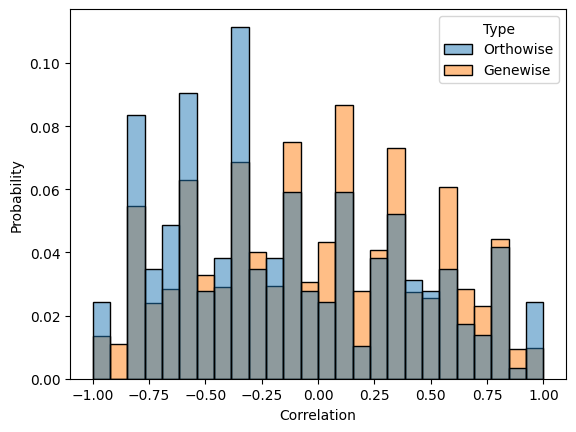

In [138]:
sns.histplot(plotting_df, x = 'Correlation', hue = 'Type', common_norm = False, stat = 'probability')

In [139]:
list_of_orthowise_correlations

[np.float64(0.4285714285714286),
 np.float64(-0.942857142857143),
 np.float64(0.6),
 np.float64(0.08571428571428573),
 np.float64(-0.7142857142857143),
 np.float64(-0.2),
 np.float64(0.4285714285714286),
 np.float64(-0.6),
 np.float64(0.7142857142857143),
 np.float64(0.2571428571428572),
 np.float64(0.4285714285714286),
 np.float64(0.2),
 np.float64(-0.6571428571428573),
 np.float64(0.3714285714285715),
 np.float64(-0.7714285714285715),
 np.float64(0.7714285714285715),
 np.float64(0.3142857142857143),
 np.float64(-0.7142857142857143),
 np.float64(-0.11595420713048968),
 np.float64(0.942857142857143),
 np.float64(-0.3714285714285715),
 np.float64(-0.6),
 np.float64(-0.14285714285714288),
 np.float64(-0.2),
 np.float64(-0.2),
 np.float64(-0.48571428571428577),
 np.float64(0.8285714285714287),
 np.float64(-0.2571428571428572),
 np.float64(0.4285714285714286),
 np.float64(-0.7714285714285715),
 np.float64(-0.6571428571428573),
 np.float64(0.08571428571428573),
 np.float64(-0.82857142857142